# <center>MDSA D209 Data Mining I</center> 

## <center>Task 1  Classification Analysis Rev.4</center>

## <center>Justin Jordan</center>

## <center>7/15/2025</center>

## <center>WGU</center>



## Part I: Research Question

### A.  Describe the purpose of this data mining by doing the following:

1.  Propose one question relevant to a real-world organizational situation that you will answer using one of the following classification methods:

        •   k-nearest neighbor (KNN)

        •   Naive Bayes

    - Can we predict a customer's churn based on the available data within the churn dataset?  I believe this is an important question to an organization as it costs 10 times more to acquire a new customer than to retain an existing one(Churn Data Consideration and Dictionary 2024).  K-Nearest Neighbor(KNN) will be used to answer the question.  

2.  Define one goal of the data analysis. Ensure that your goal is reasonable within the scope of the scenario and is represented in the available data.
    - The goal of this analysis is to identify customers whom are more likely to churn based upon factors within the dataset.  If we are able to predict a customer's churn, the company can have a strategy in place to help prevent churn of a customer.     

## Part II: Method Justification

### B.   Explain the reasons for your chosen classification method from part A1 by doing the following::

1.   Explain how the classification method you chose analyzes the selected data set. Include expected outcomes.
    - The k-nearest neighbors (KNN) algorithm is a non-parametric, supervised learning classifier, which uses proximity to make classifications or predictions about the grouping of an individual data point.  While the KNN algorithm can be used for either regression or classification problems, it is typically used as a classification algorithm, working off the assumption that similar points can be found near one another.(IBM, What is the K-nearest neighbors algorithm? 2025)  We will be using KNN classification to assign the class label most common among the nearest neighbors to the new data point based off the use of a majority voting system.  The expected outcome should show how the target variable(Churn) in relation to the neighbors.    

2.  Summarize one assumption of the chosen classification method.
    -   One assumption of the KNN classification is that the closer the two points are, the more related they are to each other.  

3.  List the packages or libraries you have chosen for Python and justify how each item on the list supports the analysis.
    -  In this analysis, we will be using Python within a Jupyter notebook. This gives us the ease and flexibility to have code and markdown cells in one easy to follow document. Python combined with Jupyter make it easy for not only implementing and reading code, but also creating the visual representations of the code all in one place making it easier to understand the data that is being worked with.  Packages that will be used within Python are as follows:
        - Pandas and Numpy for preperation and analysis
        - Seaborn and Matplotlib for data visualization
        - Scikit-learn for machine learning and predictive modeling
        - Scypy for statistics and normalization
        

## Part III: Data Preparation

### C.  Perform data preparation for the chosen data set by doing the following:

1.  Describe one data preprocessing goal relevant to the classification method from part A1.
- The goal is to have a clean data set that can be used for KNN Classification mentioned in above.  In order to ensure the data set is properly prepared for KNN Classification, any categorical variables will need encoded to numeric.  


2.  Identify the initial data set variables that you will use to perform the analysis for the classification question from part A1 and classify each variable as numeric or categorical.
- Dependent variable(X)
    - Churn(categorical)
- Independent variables(Y)
    - Age(numeric)
    - Income(numeric)
    - Outage_sec_perweek(numeric)
    - Yearly_equip_failure(numeric)
    - Techie(categorical)
    - Tablet(categorical)
    - Phone(categorical)
    - OnlineSecurity(categorical)
    - DeviceProtection(categorical)
    - TechSupport(categorical)
    - StreamingMovies(categorical)
    - Tenure(numeric)
    - MontlyCharge(numeric)

3. Explain each of the steps used to prepare the data for the analysis. Identify the code segment for each step.
    - needed packages will be imported into Python
    - pd.read_csv will be used to load data frame
    - .info() will be used to profile data frame
    - inspect data frame for duplicate values
    - .isnull().sum will be used to identify possible missing values
    - if missing values exist, they will be treated with imputation
    - identify outliers
    - encoding of categorical variables to dummy variables
    - data normalization of numeric variables
    - save prepared data to csv
    
4. Provide a copy of the cleaned data set.

- Code for C3 & C4 is below.

In [20]:
# code for c3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# code for data frame
churn = pd.read_csv("C:/users/jjord/Documents/WGU/D209/PA1/Rev4/churn_clean.csv")

# Profile of Data Frame
churn.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [21]:
# Missing values using isnull
churn.isnull().sum()

CaseOrder                  0
Customer_id                0
Interaction                0
UID                        0
City                       0
State                      0
County                     0
Zip                        0
Lat                        0
Lng                        0
Population                 0
Area                       0
TimeZone                   0
Job                        0
Children                   0
Age                        0
Income                     0
Marital                    0
Gender                     0
Churn                      0
Outage_sec_perweek         0
Email                      0
Contacts                   0
Yearly_equip_failure       0
Techie                     0
Contract                   0
Port_modem                 0
Tablet                     0
InternetService         2129
Phone                      0
Multiple                   0
OnlineSecurity             0
OnlineBackup               0
DeviceProtection           0
TechSupport   

In [22]:
# look at unique values for InternetService
churn.InternetService.unique()

array(['Fiber Optic', 'DSL', nan], dtype=object)

In [23]:
# Impute nulls for InternetService
churn["InternetService"].fillna("No Internet Service", inplace=True)

In [24]:
# verify InternetService no longer has nulls
churn["InternetService"].isnull().sum()

0

Columns Zip, Lat, Lng currently are floats or ints. There are not quantitative so will change datatype to object. These values are not meant for any type of calculation. Since the rest of the data types for categorical are set to object, these will aslo.

In [25]:
obj_columns = ["Zip", "Lat", "Lng"]
churn[obj_columns] = churn[obj_columns].astype(object)

In [26]:
# rename item columns
churn.rename(
    columns={
        "Item1": "Timely_response",
        "Item2": "Timely_fixes",
        "Item3": "Timely_replacements",
        "Item4": "Reliability",
        "Item5": "Options",
        "Item6": "Respectful_response",
        "Item7": "Courteous_exchange",
        "Item8": "Active_listening",
    },
    inplace=True,
)

In [27]:
#profile df after clean
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  object 
 8   Lat                   10000 non-null  object 
 9   Lng                   10000 non-null  object 
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [28]:
# code for outliers.
churn.describe()

,CaseOrder,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year,Timely_response,Timely_fixes,Timely_replacements,Reliability,Options,Respectful_response,Courteous_exchange,Active_listening
count,10000.00000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,9756.562400,2.0877,53.078400,39806.926771,10.001848,12.016000,0.994200,0.398000,34.526188,172.624816,3392.341550,3.490800,3.505100,3.487000,3.497500,3.492900,3.497300,3.509500,3.495600
std,2886.89568,14432.698671,2.1472,20.698882,28199.916702,2.976019,3.025898,0.988466,0.635953,26.443063,42.943094,2185.294852,1.037797,1.034641,1.027977,1.025816,1.024819,1.033586,1.028502,1.028633
min,1.00000,0.000000,0.0000,18.000000,348.670000,0.099747,1.000000,0.000000,0.000000,1.000259,79.978860,155.506715,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,738.000000,0.0000,35.000000,19224.717500,8.018214,10.000000,0.000000,0.000000,7.917694,139.979239,1236.470827,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,5000.50000,2910.500000,1.0000,53.000000,33170.605000,10.018560,12.000000,1.000000,0.000000,35.430507,167.484700,3279.536903,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
75%,7500.25000,13168.000000,3.0000,71.000000,53246.170000,11.969485,14.000000,2.000000,1.000000,61.479795,200.734725,5586.141370,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,10000.00000,111850.000000,10.0000,89.000000,258900.700000,21.207230,23.000000,7.000000,6.000000,71.999280,290.160419,7158.981530,7.000000,7.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000


In [29]:
from sklearn.preprocessing import MinMaxScaler

#create separate dataframes for continuous & categorical variables
churn_con = churn[['Age', 'Income', 'Outage_sec_perweek', 'Yearly_equip_failure', 'Tenure', 'MonthlyCharge']]
churn_cat = churn[['Techie', 'Tablet', 'Phone', 'OnlineSecurity', 'DeviceProtection', 'TechSupport', 'StreamingMovies']]

#replace yes & no with 1 & 0
#churn[churn_cat] = churn[churn_cat].replace({'Yes': 1, 'No': 0})
churn_cat = churn_cat.replace({'No': 0, 'Yes': 1})

#one hot encode categorical, dropping first level of each
churn_cat_encode = pd.get_dummies(churn_cat,drop_first=True)

#scale numeric only
scaler = MinMaxScaler()
churn_con_scale = pd.DataFrame(scaler.fit_transform(churn_con), columns=churn_con.columns)


#column concatenate
data = pd.concat([churn_con_scale, churn_cat_encode], axis=1)

data['Churn'] = churn['Churn'].map({'No': 0, 'Yes': 1})

#dependent variable churn to binary
x = data.drop('Churn', axis=1)
y = data['Churn']




In [30]:
#c4 prepped data set
data.to_csv('prep_churn.csv', index=False)

## Part IV: Analysis

### D.  Perform the data analysis and report on the results by doing the following:
1.  Split the data into training and test data sets and provide the file(s). 

In [31]:
# d1 code
from sklearn.model_selection import train_test_split


#split into test and train
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=7, stratify = y)



#files to csv
x_train.to_csv('x_train.csv', index=False)
x_test.to_csv('x_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)






### D2
2.  Describe the analysis technique you used to appropriately analyze the data. Include screenshots of the intermediate calculations you performed.
    - The k-nearest neighbors (KNN) algorithm is a non-parametric, supervised learning classifier, which uses proximity to make classifications or predictions about the grouping of an individual data point.  While the KNN algorithm can be used for either regression or classification problems, it is typically used as a classification algorithm, working off the assumption that similar points can be found near one another.(IBM, What is the K-nearest neighbors algorithm? 2025)  We will be using KNN classification to assign the class label most common among the nearest neighbors to the new data point based off the use of a majority voting system.  The expected outcome should show how the target variable(Churn) in relation to the neighbors.

    - The K value can be chosen at random but hyperparameter tuning can be used to set the K value.  Hyperparameter tuning is not required as part of the task so it will not be used.  This task does require intermediate calculations be shown.  For that reason, the K value will be chosen based on the square root of the number of samples to satisfy that requirement.      


In [32]:
#intermediate calculation requirement
#square root 
print("K Value: " + str(np.sqrt(len(x_train))))

K Value: 83.66600265340756


### D3
3. Code is below for section D3

In [33]:
#D3 code
#package import
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import  roc_auc_score

#knn classifier
#k value set using square root value from previous section
knn = KNN(n_neighbors=84)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
y_pred_prob = knn.predict_proba(x_test)[:,1]

# print accuracies
print("Train Accuracy: " + str(knn.score(x_train, y_train)))
print("Test Accuracy: " + str(knn.score(x_test, y_test)))

#print AUC 
print("AUC: " + str(roc_auc_score(y_test, y_pred_prob)))

Train Accuracy: 0.8157142857142857
Test Accuracy: 0.8216666666666667
AUC: 0.862820633494488


## Part V:  Data Summary and Implications

### E. Summarize your data analysis by doing the following:
1. Explain the accuracy and the area under the curve (AUC) of your classification model.

- The code and results for the accuracy and the AUC are above in the previous section.

- The accuracy of the model is .8216666666666667 or 82.1%(rounded) which means it was correct about predictions 82.1% of the time on the test dataset.  On the train dataset, it has an accuracy of .8157142857142857 or 81.5%(rounded) which is almost exactly the same as the test dataset.

- The AUC score is .862820633494488 or about 86.2% shows the model has a relatively high chance of being able to predict a customer's churn.  An AUC score of 1 or 100% being a perfect model.  86%(rounded) accuracy can be considered a well performing model.  

- The ROC curve shows a visualzation of the AUC score above.  You can see the curve is well above the dotted line that represents 50%.  With the curve being above the dotted line, it can be said the model performs well.  

- The code for the visualaztion of the AUC(ROC Curve) is below.  

- Even though not required in this task, a confusion matrix, specificity and sensitivity are also provided below to help with looking at model performance insight.  The specificity of the model is .920, suggesting the model does well at predicting false churn.  From the confusion matrix, out of 795, the model correctly predicted churn 435 times.  The sensitivity shows that at .547(rounded).     

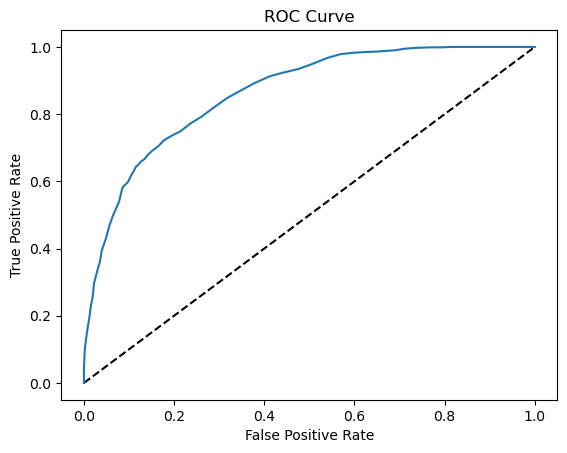

In [34]:
#E1 code
#roc curve
from sklearn.metrics import roc_curve


fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [35]:
#confusion matrix
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
title_list = ["Actual False", "Actual True"]
conf_matrix_df = pd.DataFrame(conf_matrix, columns = ["Model Predicted False", "Model Predicted True"])
conf_matrix_df.insert(0, " ", title_list)
conf_matrix_df["Model Predicted False"] = conf_matrix_df["Model Predicted False"].astype("int64")
conf_matrix_df["Model Predicted True"] = conf_matrix_df["Model Predicted True"].astype("int64")
print(conf_matrix_df)


                 Model Predicted False  Model Predicted True
0  Actual False                   2030                   175
1   Actual True                    360                   435


In [36]:
#specificity and sensitivity calculations

#specificity
true_neg = conf_matrix[0,0]
true_pos = conf_matrix[1,1]
false_neg = conf_matrix[1,0]
false_pos = conf_matrix[0,1]
specificity = (true_neg)/(true_neg + false_pos)

#sensitivity
sensitivity = (true_pos)/(true_pos + false_neg)

#print specificity and sensitivity
print("Specificity = " + str(specificity))
print("Sensitivity = " + str(sensitivity))

Specificity = 0.9206349206349206
Sensitivity = 0.5471698113207547


### E2  


2.  Discuss the results and implications of your classification analysis.

- The classification model predicted the churn of a customer with 82.1% accuracy and an AUC score of 86.2%.  The confusion matrix shows the model made 435 correct predictions of churn out of a total of 795(360 + 435).  It is possible the data itself is skewed with the number of customers whom churned. The sensitivity of the model is .547 which is barely more than 50%.  Due to the sensitivity being what I consider less than optimal, other prediction techniques should be explored.       


3.  Discuss one limitation of your data analysis.

- The main limitation of the analysis would be that KNN is prone to overfitting.  While feature selection and dimensionality reduction techniques are leveraged to prevent this from occurring, the value of k can also impact the model’s behavior. Lower values of k can overfit the data, whereas higher values of k tend to “smooth out” the prediction values since it is averaging the values over a greater area, or neighborhood. However, if the value of k is too high, then it can underfit the data.(IBM, What is the K-nearest neighbors algorithm? 2025)   

4. Recommend a course of action for the real-world organizational situation from part A1 based on your results and implications discussed in part E2.

- While there is some statistical certainty in the models ability to predict a customers churn according to the model, it would be recommended further analysis be done using different variables as well as other prediction techniques be explored based upon the results of the confusion matrix as well as the sensitivity and specificity.  After further analysis has been done, the company can then make an informed decision on the research question.

## Part VI: Demonstration

### F.  Provide a Panopto video recording that includes the presenter and a vocalized demonstration of the functionality of the code used for the analysis of the programming environment.



- https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=f2757265-c0d9-4ede-957b-b31b016a2c4c

### G.  List the web sources used to acquire data or segments of third-party code to support the application. Ensure the web sources are reliable.
    None used.

### H.  Acknowledge sources, using in-text citations and references, for content that is quoted, paraphrased, or summarized.
    WGU. (n.d.). Churn Data Consideration and Dictionary. Data Files and Associated Dictionary Files. https://access.wgu.edu/ASP3/aap/content/d9rkejv84kd9rk30fi2l.zip 

    IBM. (2025, June 4). What is the K-nearest neighbors algorithm? https://www.ibm.com/think/topics/knn 